In [13]:
import numpy as np

In [14]:
import pandas as pd
Patients=pd.read_csv('Patients.csv')
diagnosis=pd.read_csv('diagnosis.csv')
Outcomes=pd.read_csv('Outcomes .csv')
Labs=pd.read_csv('Labs.csv')

In [15]:
Patients=Patients.merge(diagnosis, on='Diagnosis ID', how='left')
Patients=Patients.merge(Outcomes, on='Outcome ID', how='left')

In [16]:
Patients['Admission Date']=pd.to_datetime(Patients['Admission Date'])

In [37]:
Patients['OutcomeEncoded']=Patients['Outcome'].map({'Recovered':0,'Deceased':1,'Complicated':1})

In [36]:
Patients['HighRisk']=np.where((Patients['Age']>65) | (Patients['Outcome']=='Complicated') | (Patients['Outcome']=='Deceased'),1,0)

In [19]:
abnormal_conditions={
    'Blood Sugar':lambda x: x>120,
    'Cholesterol':lambda x: x>200,
    'Hemoglobin':lambda x: x<12
}
def count_abnormal_conditions(Patient_ID):
    Patient_labs=Labs[Labs['Patient ID']==Patient_ID]
    count=0
    for Test_Name,condition in abnormal_conditions.items():
        Result=Patient_labs[Patient_labs['Test Name']==Test_Name][' Result']
        if not Result.empty and condition(Result.values[0]):
            count+=1
            return count
        Patients['AbnormalConditionsCount']=Patients['Patient ID'].apply(count_abnormal_conditions)

In [43]:
feautures=Patients[['Age','HighRisk']]
target=Patients['OutcomeEncoded']

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(feautures, target, test_size=0.3, random_state=42)

In [30]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [45]:
import sklearn.linear_model as im
print(im.__file__)
print(hasattr(im, 'LogisticRegression'))

c:\Users\aksha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\__init__.py
True


In [46]:
model=im.LogisticRegression(max_iter=500)
model.fit(X_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in

In [47]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred=model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.54      0.70        24
           1       0.82      1.00      0.90        51

    accuracy                           0.85        75
   macro avg       0.91      0.77      0.80        75
weighted avg       0.88      0.85      0.84        75



In [39]:
Patients['OutcomeEncoded'].isna().sum()

np.int64(0)

In [42]:
Patients['Outcome ID'].value_counts(dropna=False)

Outcome ID
O001    87
O002    85
O003    78
Name: count, dtype: int64

In [32]:
Outcomes.columns

Index(['Outcome ID', 'Outcome'], dtype='str')

In [33]:
Outcomes.head()

,Outcome ID,Outcome
0,O001,Recovered
1,O002,Deceased
2,O003,Complicated


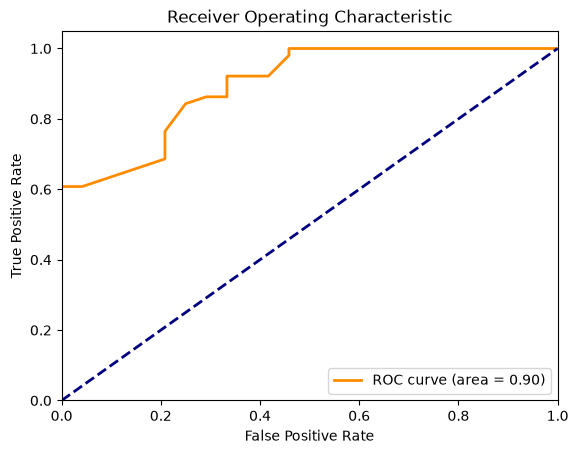

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
y_prob=model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds=roc_curve(y_test, y_prob)
roc_auc=auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [51]:
import joblib
joblib.dump(model, 'risk_model.pkl')

['risk_model.pkl']

In [1]:
pip install streamlit

   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   -----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
import streamlit as st
import pandas as pd
import joblib
l=joblib.load('risk_model.pkl')
st.title("Healthcare Risk Prediction Model")
age=st.number_input("Enter Age:", min_value=0, max_value=120, value=30)
Test1=st.number_input("Enter Blood Sugar Level:", min_value=0, max_value=500, value=100)
Test2=st.number_input("Enter Cholesterol Level:", min_value=0, max_value=500, value=150)
if st.button("Predict Risk"):
    HighRisk=1 if age>65 or Test1>120 or Test2>200 else 0
    input_data=pd.DataFrame({'Age':[age],'HighRisk':[HighRisk]})
    prediction=l.predict(input_data)
    risk="High Risk" if prediction[0]==1 else "Low Risk"
    st.write(f"The predicted risk is: {risk}")
    

2026-09-25 18:49:32.790 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-25 18:49:33.647 
  command:

    streamlit run C:\Users\aksha\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-25 18:49:33.648 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-25 18:49:33.648 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-25 18:49:33.649 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-25 18:49:33.649 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-25 18:49:33.650 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-25 18:49:33.651 Sess

: 